 docTR: Document Text Recognition
 https://mindee.github.io/doctr/index.html

In [556]:
import numpy as np
import os 
import cv2
import re
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from doctr.models import ocr_predictor
from enum import Enum
from typing import Final
from IPython.display import display
import random

import torch
from doctr.models import recognition, detection
from doctr.datasets import RecognitionDataset
from doctr.transforms import Resize
from doctr.io import DocumentFile
from torch.utils.data import DataLoader
from torch.optim import AdamW

In [ ]:
# Definiciones Globales

# Etiquetas de Busqueda de Texto en Ticket
# Estas etiquetas estan en todos los Tickets 
# Se utilizaran para delimitar el area (box, Rect) 
# donde se encuentran los datos (Columnas con cadenas de 5 Digitos)
# que conforman el codigo
LABELS_START = [ "HORA:", "H0RA:", "HORA", "H0RA", "COL", "C0L", "FIRMA"]
LABELS_END = ["MONTO:", "M0NTO:", "MONT0:", "M0NT0:", "CARGO", "CARG0", "SERVI", "IMP.", "TOTAL:", "T0TAL:"]


# Procentaje minimo de confiabilidad 
# Si la confiabilidad (score) del texto que se obtuvo al
# encontrar las cadenas de 5 digitos es menor a este valor
# indicar que el codigo resultado puede tener errores de
# decifrado de los numeros 
# Por ejemplo un 0 (cero) interpretarlos como 8 o viceversa

SCORE_MIN_DOCTR = 0.85
# Codigo no encontrado
COL_FAILED = "***** *****"
DIG_FAILED = "*****"

# Resultados
RESULTADO_ARCHIVO : Final[str] = "archivo"
RESULTADO_COL_1 : Final[str] = "COL_1"
RESULTADO_COL_2 : Final[str] = "COL_2"
RESULTADO_COL_3 : Final[str] = "COL_3"



# Dataframes FIELDS Names
DF_CODIGO : Final[str] = "codigo"
DF_SUCCESS : Final[str] = "success"
DF_TOP : Final[str] = "top"
DF_BOTTOM : Final[str] = "bottom"


DOCTR_PAGES: Final[str] = "pages"
DOCTR_BLOCKS : Final[str] = "blocks"
DOCTR_LINES : Final[str] = "lines"
DOCTR_WORDS : Final[str] = "words"
DOCTR_GEOMETRY : Final[str] = "geometry"
DOCTR_VALUE : Final[str] = "value"
DOCTR_CONFIDENCE : Final[str] = 'confidence'


OCR_DOCTR : Final [str] = "DocTR"

CODE_SUCCESS : Final[int] = 0
CODE_ERRORARCHIVO : Final[int] = 1
CODE_NOSTARTLABELS : Final[int] = 2
CODE_BLOQUES5DIG : Final[int] = 3
CODE_NOENDLABELS : Final[int] = 4
CODE_CODIGONOVALIDO : Final[int] = 5
CODE_LOWCONFIDENCE : Final[int] = 6

CODES_DESCRIPCION = ["Codigo Extraido con Exito", 
                     "Error al aplicar OCR , sin resultado", 
                     "No se encontraron etiquetas de inicio (LABELS_START)", 
                     "No se encontradon bloques de 5 digitos suficientes", 
                     "No se encontraron etiquetas de Final (LABELS_END)", 
                     "Codigo No Valido"]



In [ ]:
# Carpeta donde estan guardas los archivos de imagen de Tickets
FOLDER_PATH = r"C:\Users\arant\OneDrive\Escritorio\20260121 imagenes Cashcollection"
REALES_PATH = r"C:\Users\arant\Downloads\doctr\codigosticketsreales.csv"
LABELS_JSON = r"C:\Users\arant\Downloads\doctr\labels.json"
TICKETS_EXT_PATH = r"C:\Users\arant\Downloads\doctr\ticketsextraidos.csv"
EFECTDOCTR_PATH = r"C:\Users\arant\Downloads\doctr\efectividadDoctr.csv"

# Obtener Lista de Archivos dentro de Carpeta
ARCHIVOS = [
        f for f in os.listdir(FOLDER_PATH)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".jfif"))
        ]

In [ ]:
# Modelo OCR de DOCTR para revision de tickets (antes de entrenamiento)
model = ocr_predictor('db_resnet50', 'crnn_vgg16_bn', pretrained=True)

n=0

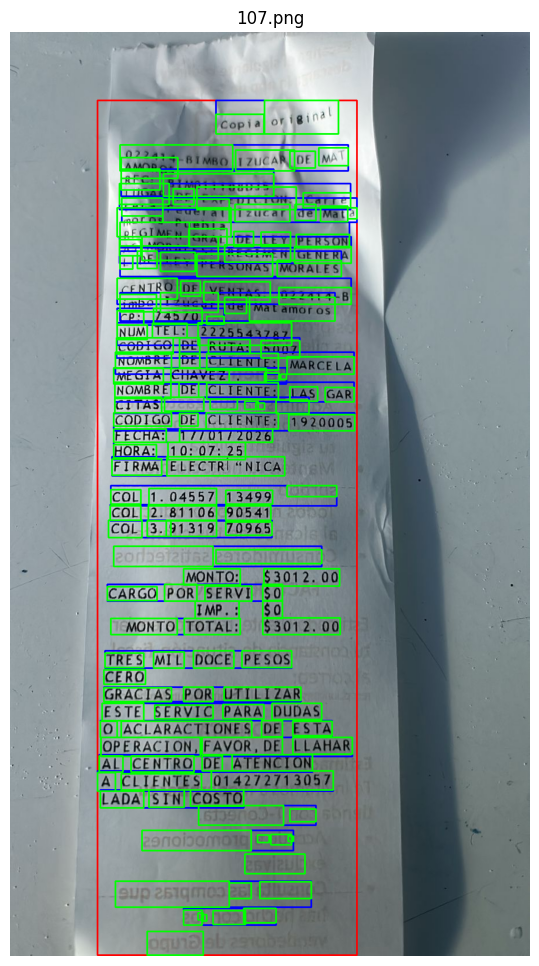

In [709]:
# Revision de todos los tickets para obtener archivo de Excel con codigos reales
# para entrenamiento del modelo

file_name = ARCHIVOS[n]
image = cv2.imread(f"{FOLDER_PATH}/{file_name}")


# Obtener dimensiones de imagen , se requieren porque DOCTR regresa coordenadas de ubicacion del texto 
# en porcentajes relativos a las dimensiones 
h, w = image.shape[:2] 

# Aplicar Modelo d DocTR a Imagen
resultsDocTR = model([image])
result_json = resultsDocTR.export()

rectBlocks = []
rectLines = []
rectwords = []

# Leer lineas de JSON buscando datos de COLs
for block in result_json[DOCTR_PAGES][0][DOCTR_BLOCKS]:
    # Ciclo de Lineas Encontradas
    boxblock = block[DOCTR_GEOMETRY]
    xmin = int(boxblock[0][0] * w)
    ymin = int(boxblock[0][1] * h)
    xmax = int(boxblock[1][0] * w)
    ymax = int(boxblock[1][1] * h)
    rectBlocks.append([(xmin, ymin), (xmax, ymax)])

    for line in block[DOCTR_LINES]:
        # Ciclo de Palabras Encontradas
        boxline = line[DOCTR_GEOMETRY]
        xmin = int(boxline[0][0] * w)
        ymin = int(boxline[0][1] * h)
        xmax = int(boxline[1][0] * w)
        ymax = int(boxline[1][1] * h)
        rectLines.append([(xmin, ymin), (xmax, ymax)])

        for word in line[DOCTR_WORDS]:
            # Obtener Texto 
            palabra = word[DOCTR_VALUE]
            boxword = word[DOCTR_GEOMETRY]
            xmin = int(boxword[0][0] * w)
            ymin = int(boxword[0][1] * h)
            xmax = int(boxword[1][0] * w)
            ymax = int(boxword[1][1] * h)

            # Compara Palabras con Etiquestas de Inicio (LABELS_START)     
            rectwords.append([(xmin, ymin), (xmax, ymax)])


for rect in rectBlocks :
    cv2.rectangle(image, (rect[0]), (rect[1]), (255,0,0), 2)

for rect in rectLines:
    cv2.rectangle(image, (rect[0]), (rect[1]), (0, 0,255), 2)

# Mostrar Rectangulo alrededor de los bloques de Texto del presunto codigo detectados
for rect in rectwords :
    cv2.rectangle(image, (rect[0]), (rect[1]), (0,255,0), 2)


# Mostrar Imagenes resultantes
plt.figure(figsize=(20, 12))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(file_name)
plt.axis('off')


n += 1

In [ ]:
# Leer Archivo de Codigos Reales para generar DataFrame
df_tickets = pd.read_csv(REALES_PATH)
df_tickets

,archivo,COL_1,COL_2,COL_3
0,348.png,COL 1. 12837 92743,COL 2. 56300 00894,COL 3. 53535 08851
1,374.png,COL 1. 16579 72589,COL 2. 71314 01595,COL 3. 63531 14034
2,base64decoded - 2026-01-21T151846.052.png,COL 1. 64806 06062,COL 2. 16007 20851,COL 3. 50498 02985
3,360.png,COL 1. 82359 81604,COL 2. 63366 06595,COL 3. 83830 34528
4,base64decoded - 2026-01-21T154223.919.png,COL 1. 16189 17608,COL 2. 41667 56315,COL 3. 86800 46054
...,...,...,...,...
840,379.png,COL 1. 71149 18004,COL 2. 71008 30322,COL 3. 40389 48927
841,base64decoded (80).png,COL 1. 50724 30469,COL 2. 31109 90740,COL 3. 61319 28012
842,base64decoded - 2026-01-21T154206.619.png,COL 1. 47551 37002,COL 2. 50609 50516,COL 3. 46505 55624
843,351.png,COL 1. 21502 94050,COL 2. 51106 90571,COL 3. 91478 71673


In [ ]:
# Generar archivos JSON para entrenamiento del Modelo
# se especifican las columnas COL 1, COL 2 y COL 3 de cada
# ticket
# https://mindee.github.io/doctr/using_doctr/custom_models_training.html
# Text recognition Training
# https://github.com/mindee/doctr/tree/main/references/recognition#readme

last = len(df_tickets)
rownumber = 1
with open(LABELS_JSON, 'w', encoding="utf-8") as f:
    f.write("{\n")
    for row in df_tickets.itertuples() :
        endline = ",\n" if last>rownumber else  "\n"   # Evitar colocar coma (,) en la ultima linea
        f.write("\t\"" + row.archivo + "\" : \"" + row.COL_1 + "\"" + ",\n")
        f.write("\t\"" + row.archivo + "\" : \"" + row.COL_2 + "\"" + ",\n")
        f.write("\t\"" + row.archivo + "\" : \"" + row.COL_3 + "\"" + endline)
        rownumber += 1
    f.write("}")


In [ ]:
# Entrenar Modelo utilizando archivo JSON de Codigos Reales obtenidos manualmente
# Aplicando 50 Epocs

print("--- 3. INICIANDO ENTRENAMIENTO DocTR ---")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Aumentamos el ancho a 128 píxeles para acomodar frases más largas (64 pasos de tiempo)
train_set = RecognitionDataset(
    img_folder=FOLDER_PATH,
    labels_path=LABELS_JSON,
    img_transforms=Resize((32, 128)),
)

# 2. FILTRO DE RUIDO: Descartar recortes masivos (> 60 caracteres) que rompen la pérdida CTC
train_set.data = [(path, label) for path, label in train_set.data if len(label) <= 60]
print(f"Recortes válidos tras filtrar textos gigantes: {len(train_set.data)}")

train_loader = DataLoader(
    train_set,
    batch_size=2,
    shuffle=True,
    collate_fn=train_set.collate_fn,
)

vocabulario_completo = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.,:;?!-_~@#$%^&*()[]{}+=<>\"'\/ "

# Modelo CRNN pre-entrenado
model_doctr = recognition.crnn_vgg16_bn(pretrained=True,  vocab=vocabulario_completo).to(device)
model_doctr.train()

optimizer = AdamW(model_doctr.parameters(), lr=1e-4)
epochs = 50

for epoch in range(epochs):
    epoch_loss = 0
    for batch in train_loader:
        images, targets = batch
        images = images.to(device)

        optimizer.zero_grad()
        out = model_doctr(images, targets)
        loss = out['loss']

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Época {epoch+1}/{epochs} | Pérdida de DocTR: {epoch_loss/len(train_loader):.4f}")

print("✅ Fine-Tuning de DocTR completado.")

<>:26: SyntaxWarning: "\/" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\/"? A raw string is also an option.
<>:26: SyntaxWarning: "\/" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\/"? A raw string is also an option.
C:\Users\arant\AppData\Local\Temp\ipykernel_6740\132977806.py:26: SyntaxWarning: "\/" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\/"? A raw string is also an option.
  vocabulario_completo = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.,:;?!-_~@#$%^&*()[]{}+=<>\"'\/ "


--- 3. INICIANDO ENTRENAMIENTO DocTR ---
Recortes válidos tras filtrar textos gigantes: 845
Época 1/50 | Pérdida de DocTR: 4.5673
Época 2/50 | Pérdida de DocTR: 2.4392
Época 3/50 | Pérdida de DocTR: 2.1660
Época 4/50 | Pérdida de DocTR: 2.0231
Época 5/50 | Pérdida de DocTR: 1.9151
Época 6/50 | Pérdida de DocTR: 1.8381
Época 7/50 | Pérdida de DocTR: 1.7760
Época 8/50 | Pérdida de DocTR: 1.7213
Época 9/50 | Pérdida de DocTR: 1.6659
Época 10/50 | Pérdida de DocTR: 1.6082
Época 11/50 | Pérdida de DocTR: 1.5621
Época 12/50 | Pérdida de DocTR: 1.5247
Época 13/50 | Pérdida de DocTR: 1.5003
Época 14/50 | Pérdida de DocTR: 1.4771
Época 15/50 | Pérdida de DocTR: 1.4608
Época 16/50 | Pérdida de DocTR: 1.4459
Época 17/50 | Pérdida de DocTR: 1.4332
Época 18/50 | Pérdida de DocTR: 1.4241
Época 19/50 | Pérdida de DocTR: 1.4157
Época 20/50 | Pérdida de DocTR: 1.4068
Época 21/50 | Pérdida de DocTR: 1.3995
Época 22/50 | Pérdida de DocTR: 1.3929
Época 23/50 | Pérdida de DocTR: 1.3880
Época 24/50 | Pérdid

In [ ]:
# Configurar Predictor y pasar el resultado del entrenamiento
# Se coloco el parametro paragraph_break para evitar saltos de linea 
# Se utiliza como primer intento
predictor = ocr_predictor(
    det_arch='db_resnet50',
    reco_arch='crnn_vgg16_bn',
    pretrained=True,
    paragraph_break = 0.05,
    preserve_aspect_ratio = True,
    symmetric_pad = True
)

# Pasar datos de entrenamiento
predictor.reco_model = model_doctr
predictor.eval()

# Configurar Predictor con deteccion de orientacion
# para intentar extraer codigos con tickets inclinados
# o girados , se usa como segundo intento debido a que
# se aumenta significativamente el tiempo que le toma
# al modelo extraer los codigos

predictor_orientation = ocr_predictor(
    det_arch='db_resnet50',
    reco_arch='crnn_vgg16_bn',
    pretrained=True,
    paragraph_break = 0.05,
    preserve_aspect_ratio = True,
    symmetric_pad = True,
    assume_straight_pages=False,
    straighten_pages=True,
    detect_orientation=True 
)

# Pasar datos de entrenamiento
predictor_orientation.reco_model = model_doctr
predictor_orientation.eval()


OCRPredictor(
  (det_predictor): DetectionPredictor(
    (pre_processor): PreProcessor(
      (resize): Resize(output_size=(1024, 1024), interpolation='bilinear', preserve_aspect_ratio=True, symmetric_pad=True)
      (normalize): Normalize(mean=(0.798, 0.785, 0.772), std=(0.264, 0.2749, 0.287))
    )
    (model): DBNet(
      (feat_extractor): IntermediateLayerGetter(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [623]:
# Funciones para leer los bloques de texto de 5 digitos dentro
# de las etiquetas de inicio (LABELS_START) y etiquetas de final (LABELS_END)
# Las etiquestas LABELS_START (HORA, COL, FIRMA) se encuentran en todos
# los tickets antes de donde se ubican los bloques de 5 digitos que conforman
# el codigo que se desea extraer de cada ticket
# las etiquetas LABELS_START(MONTO,CARGO. TOTAL) se encuentran despues de los bloques
# Se buscan para solo considerar el texto entre ellas para la
# deteccion del codigo
# Se obtiene 
# los bloques de 5 digitos (bloques) 
# score minimo de confianbilidad (minscore)
#  y las coordenas Y (verticales) de inicio y final de las etiquetas (top, bottom)


# Utilizando OCr de docTR
def getBloquesTextoEntreEtiquetasDocTR(result_json, w, h, show) :

    start = False
    end = False
    minscore = 0.99
    bloques = []
    top = 0
    bottom = h

    resultcode = CODE_SUCCESS
    
    # Leer lineas de JSON buscando datos de COLs
    for block in result_json[DOCTR_PAGES][0][DOCTR_BLOCKS]:
        # Ciclo de Lineas Encontradas
        for line in block[DOCTR_LINES]:
            # Ciclo de Palabras Encontradas
            for word in line[DOCTR_WORDS]:
                # Obtener Texto 
                palabra = word[DOCTR_VALUE]
               
                box = word[DOCTR_GEOMETRY]
                # Compara Palabras con Etiquestas de Inicio (LABELS_START)
                if not start:
                    for label in LABELS_START:
                        if label in palabra:
                            start = True
                            top = int(box[0][1] * h)
                
                if start :
                    
                    if show :
                        print(palabra)

                    # Compara Palabras con Etiquestas de Final (LABELS_END)
                    for label in LABELS_END:
                        if label in palabra:
                            end = True
                            bottom = int(box[1][1] * h)
                            break
                    
                    digitos_5 = re.findall(r"\d{5}", palabra)
                    # si se encontro al menos una cadena de 5 digitos
                    if len(digitos_5)>=1 :
                       
                        xmin = int(box[0][0] * w)
                        ymin = int(box[0][1] * h)
                        xmax = int(box[1][0] * w)
                        ymax = int(box[1][1] * h)
                        score = float(word[DOCTR_CONFIDENCE])
                        minscore = min(score, minscore)
                        bloques.append(([(xmin, ymin), (xmax, ymax)], digitos_5))

               
            if end :
                break

        if end :
            break

    if not start :
        resultcode = CODE_NOSTARTLABELS
    
    if start and not end :
        resultcode = CODE_NOENDLABELS 

    if start and end and len(bloques)<3 :
        resultocode = CODE_BLOQUES5DIG

                    
    return bloques, round(minscore,2), (top, bottom), resultcode


In [624]:
# Ordenar bloques con coordenada Y , de arriba a abajo
def ordenarBloquesDigitosArribaAbajo(bloques) :
    return bloques.sort(key=lambda y: y[0][0][1])


def simplificarBloques(bloques) :
    # Una vez ordenados por coordenas Y
    # formar una tupla de dos dimensiones (eliminar coordenada Y)
    # solo coordenada X y cadenas encontradas
    codes = []
    for bloq in bloques :
        x = bloq[0][0][0]      # Obtener la coordenada X del bloque de 5 digitos
        for n in bloq[1]:   # Recorer los bloques de 5 digitos encontrados en renglon
            codes.append((x, n)) 
    return codes

def ordenarParesdeBloquesIzqDer(codes) :

    # Primeras dos cadenas de 5 digitos (Arriba)
    topcodes = codes[:2]
    # Segundas dos cadenas de 5 digitos (Medio)
    midcodes = codes[2:4]
    # Terceras dos cadenas de 5 digitos (Abajo)
    bottomcodes = codes[4:6]

    # Ordenar cadenas por coordena X
    topcodes.sort(key=lambda x: x[0])
    midcodes.sort(key=lambda x: x[0])
    bottomcodes.sort(key=lambda x: x[0])

    return topcodes, midcodes, bottomcodes

    
def getCodigoBloquesDigitos(bloques, separador) :

    bloques.sort(key=lambda y: y[0][0][1])
    bloquesSimplificados = simplificarBloques(bloques)
    # Comprobar que se obtuvieron 6 bloques de 5 digitos
    if len(bloquesSimplificados)==6 :

        top, center, bottom = ordenarParesdeBloquesIzqDer(bloquesSimplificados)
        # columnas
        COL1 =  top[0][1] + " " + top[1][1]
        COL2 =  center[0][1] + " " + center[1][1]
        COL3 =  bottom[0][1] + " " + bottom[1][1]
    

        # codigo = unirBloquesDigitosFormarCodigo([top, center, bottom], separador)
        return [COL1, COL2, COL3], CODE_SUCCESS
    
    else :
        return [ COL_FAILED,  COL_FAILED, COL_FAILED], CODE_BLOQUES5DIG

In [679]:
# Funcion para extraer Columnas del codigo del ticket
# primero utilizando patrones (COL X. 99999 99999 ,  X .99999 9999) para identificar cada una de las columnas
# segundo utilizando las etiquetas LABELS_START y LABELS_END para buscar bloques de 5 digitos entre ellas
# y ordenarlas segun su localizacion en coordenadas de la imagen
def extraer_columnas(result, h, w, show):

    export = result.export()

    COL_1 = COL_FAILED
    COL_2 = COL_FAILED
    COL_3 = COL_FAILED

    # Resultado de cada columna
    col1_succces = False 
    col2_succces = False 
    col3_succces = False 

    # Recorrer Lineas de Texto obtenidas del predictor    
    for page in export[DOCTR_PAGES]:
        for block in page[DOCTR_BLOCKS]:
            for line in block[DOCTR_LINES]:

                # Unir palabras de la linea
                text = " ".join([w[DOCTR_VALUE] for w in line[DOCTR_WORDS]])

                if show:
                    print(text)
    
                # Comparar texto de linea con patron  "COL 1. 99999 99999"
                match_col_1 = re.search(r'C[O0]L\s*1[\.\s]*(\d{5}\s*\d{5})', text, re.IGNORECASE)
                if match_col_1 :
                    COL_1 = re.sub(r'\s+', ' ', match_col_1.group(1))
                    col1_succces = True
                else :
                    # Comparar con patron corto "1. 99999 99999"
                    match_col_1_short = re.search(r'1[\.\s]*(\d{5}\s*\d{5})', text, re.IGNORECASE)
                    if match_col_1_short :
                        digs = re.findall(r"\d{5}", match_col_1_short.group())
                        if len(digs)==2 :
                            COL_1 = " ".join(digs)
                            col1_succces = True


                # Comparar texto de linea con patron "COL 2. 99999 99999"
                match_col_2 = re.search(r'C[O0]L\s*2[\.\s]*(\d{5}\s*\d{5})', text, re.IGNORECASE)
                if match_col_2 :
                    COL_2 = re.sub(r'\s+', ' ', match_col_2.group(1))
                    col2_succces = True
                else :
                    # Comparar con patron corto "2. 99999 99999"
                    match_col_2_short = re.search(r'2[\.\s]*(\d{5}\s*\d{5})', text, re.IGNORECASE)
                    if match_col_2_short :
                        digs = re.findall(r"\d{5}", match_col_2_short.group())
                        if len(digs)==2 :
                            COL_2 = " ".join(digs)
                            col2_succces = True


                # Comparar texto de linea con patron  "COL 3. 99999 99999"
                match_col_3 = re.search(r'C[O0]L\s*3[\.\s]*(\d{5}\s*\d{5})', text, re.IGNORECASE)
                if match_col_3 :
                    COL_3 = re.sub(r'\s+', ' ', match_col_3.group(1))
                    col3_succces = True
                else :
                    # Comparar con patron corto "3. 99999 99999"
                    match_col_3_short = re.search(r'3[\.\s]*(\d{5}\s*\d{5})', text, re.IGNORECASE)
                    if match_col_3_short :
                        digs = re.findall(r"\d{5}", match_col_3_short.group())
                        if len(digs)==2 :
                            COL_3 = " ".join(digs)
                            col3_succces = True


                # Verificar si se detecto el patron de las 3 columnas   
                success = col1_succces and col2_succces and col3_succces
                if success :
                    return [COL_1, COL_2, COL_3], CODE_SUCCESS
                
    # No se detectaron completas las 3 Columnas
    # Intentar con bloques de 5 digitos entre etiquetas LABELS_START , LABELS_END
    bloquesDocTR, minscoreDocTR, (top, bottom), resultcode = getBloquesTextoEntreEtiquetasDocTR(export, w, h, show)
    if resultcode==CODE_SUCCESS:
        cols, resultcode = getCodigoBloquesDigitos(bloquesDocTR, "")
        if resultcode==CODE_SUCCESS:
            return cols, CODE_SUCCESS

    # No se detecto codigo completo
    return [COL_1, COL_2, COL_3], CODE_BLOQUES5DIG

1er Intento -> Imagen Original (predictor)
copi C DI
020489-BIMBO IXTAPALUCA
RFC: BIMO11108DJ5
LUGAR DE EXPEDICION: Carre
tera federal México - Cuaut:
la km 200 mz. 1 lote 1
REGIMEN GRAL DE LEY PERSON
AS MORALES: REGIMEN GENERA
L DE LEY PERSONAS MORALES
CENTRO DE VENTAS: 020489-E B
imbo Ixtapaluca
CP: 56535
NUM TEL: 55 3660 0632
CODIGO DE RUTA: 2845
NOMBRE DE CLIENTE: MARCELA
RUPERTO DELGADILLO
NOMBRE DE CLIENTE: ABARROT
ES EL NENE
CODIGO DE CLIENTE: 4257136
FECHA: 19/01/2026
HORA: 08:23:47
FIRMA ELECTRONICA
COL 1.85403 82587
COL 2.60315 01492
COL 3.33531 87551
['85403 82587', '60315 01492', '33531 87551']


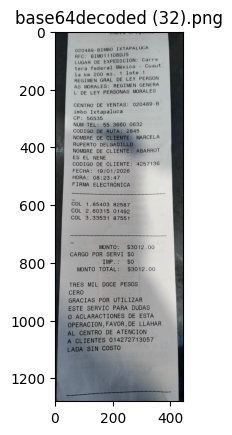

In [710]:
# Extraccion de Columnas de Ticket al azar
# Para probar las funciones de extraccion y 
# la efectividad del entrenamiento

nrandom = random.randint(0, len(ARCHIVOS) - 1)
file_name =  ARCHIVOS[nrandom]
path = os.path.join(FOLDER_PATH, file_name)

# Leer Imagen
image = cv2.imread(path)

plt.imshow(image)
plt.title(file_name)

# Obtener dimensiones de imagen , se requieren porque DOCTR regresa coordenadas de ubicacion del texto 
# en porcentajes relativos a las dimensiones 
h, w = image.shape[:2] 

# Aplicar Modelo d DocTR a Imagen
print("1er Intento -> Imagen Original (predictor)")
resultsDocTR = predictor([image])
cols, resultcode = extraer_columnas(resultsDocTR, h, w,  True)
if resultcode != CODE_SUCCESS:
    image_clean = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)
    print("2do Intento -> Imagen Clarificada (predictor)")
    resultsDocTR = predictor([image_clean])
    cols, resultcode = extraer_columnas(resultsDocTR, h, w, False)
    if resultcode != CODE_SUCCESS:
        print("3er Intento -> Imagen Original (predictor orientation)")
        resultsDocTR = predictor_orientation([image])
        cols, resultcode = extraer_columnas(resultsDocTR, h, w, False)
        if resultcode != CODE_SUCCESS :
            print("4to Intento -> Imagen Clarificada (predictor orientation)")
            resultsDocTR = predictor_orientation([image_clean])
            cols, resultcode = extraer_columnas(resultsDocTR, h, w, False)

    
print(cols)

In [ ]:
# Extraccion de columnas  de todos los Tickets
resultados = []

# Recorrer todos los archivos
for archivo in ARCHIVOS:

    # PAth de Archivo
    path = os.path.join(FOLDER_PATH, archivo)

    # Leer Imagen
    image = cv2.imread(path)
    
    # Obtener dimensiones de imagen , se requieren porque DOCTR regresa coordenadas de ubicacion del texto 
    # en porcentajes relativos a las dimensiones y no en pixeles
    h, w = image.shape[:2] 
    
    # 1er intento con Imagen original y predictor sin detecion de orientacion
    resultsDocTR = predictor([image])
    cols, resultcode = extraer_columnas(resultsDocTR, h, w,  False)
    if resultcode != CODE_SUCCESS:
        # 2do Intento con Imagen Clarificada y mismo predictor
        image_clean = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)
        resultsDocTR = predictor([image_clean])
        cols, resultcode = extraer_columnas(resultsDocTR, h, w, False)
        if resultcode != CODE_SUCCESS:
            # 3er Intento con Imagen Original con deteccion de orientacion (predictor orientation)
            resultsDocTR = predictor_orientation([image])
            cols, resultcode = extraer_columnas(resultsDocTR, h, w, False)
            if resultcode != CODE_SUCCESS :
                # 4to Intento con Imagen Clarificada con deteccion de orientacion(predictor_orientation)
                resultsDocTR = predictor_orientation([image_clean])
                cols, resultcode = extraer_columnas(resultsDocTR, h, w, False)

    # Formar Columnas
    COL_1 = "COL 1. " + cols[0]
    COL_2 = "COL 2. " + cols[1]
    COL_3 = "COL 3. " + cols[2]

    resultado = {
        RESULTADO_ARCHIVO : archivo,
        RESULTADO_COL_1 : COL_1,
        RESULTADO_COL_2 : COL_2,
        RESULTADO_COL_3 : COL_3
    }

    print(len(resultados) , resultado)

    resultados.append(resultado)

0 {'archivo': '1.jpeg', 'COL_1': 'COL 1. 15355 50899', 'COL_2': 'COL 2. 01146 94344', 'COL_3': 'COL 3. 01816 44947'}
1 {'archivo': '10.jpeg', 'COL_1': 'COL 1. 15869 47453', 'COL_2': 'COL 2. 66601 50814', 'COL_3': 'COL 3. 56408 09133'}
2 {'archivo': '100.jpg', 'COL_1': 'COL 1. 24421 97889', 'COL_2': 'COL 2. 30669 56415', 'COL_3': 'COL 3. 69800 86140'}
3 {'archivo': '101.png', 'COL_1': 'COL 1. 96476 05643', 'COL_2': 'COL 2. 00069 36425', 'COL_3': 'COL 3. 60880 89364'}
4 {'archivo': '102.png', 'COL_1': 'COL 1. 30556 59450', 'COL_2': 'COL 2. 51144 64548', 'COL_3': 'COL 3. 91826 13568'}
5 {'archivo': '103.png', 'COL_1': 'COL 1. 94051 62662', 'COL_2': 'COL 2. 20063 66578', 'COL_3': 'COL 3. 60850 53968'}
6 {'archivo': '104.png', 'COL_1': 'COL 1. 39506 74158', 'COL_2': 'COL 2. 81117 91571', 'COL_3': 'COL 3. 91374 12101'}
7 {'archivo': '105.png', 'COL_1': 'COL 1. 18889 27246', 'COL_2': 'COL 2. 06600 50810', 'COL_3': 'COL 3. 56408 06798'}
8 {'archivo': '106.png', 'COL_1': 'COL 1. 25354 80796', '

In [682]:
# COnvertir resultados en Dataframe
df_tickets_ext = pd.DataFrame(resultados)
df_tickets_ext


,archivo,COL_1,COL_2,COL_3
0,1.jpeg,COL 1. 15355 50899,COL 2. 01146 94344,COL 3. 01816 44947
1,10.jpeg,COL 1. 15869 47453,COL 2. 66601 50814,COL 3. 56408 09133
2,100.jpg,COL 1. 24421 97889,COL 2. 30669 56415,COL 3. 69800 86140
3,101.png,COL 1. 96476 05643,COL 2. 00069 36425,COL 3. 60880 89364
4,102.png,COL 1. 30556 59450,COL 2. 51144 64548,COL 3. 91826 13568
...,...,...,...,...
845,base64decoded - 2026-01-21T164518.946.jfif,COL 1. 68503 39655,COL 2. 71089 66572,COL 3. 90850 76433
846,base64decoded - 2026-01-21T164527.165.jfif,COL 1. 46562 89368,COL 2. 10156 63543,COL 3. 61523 58744
847,base64decoded - 2026-01-21T164535.581.jpg,COL 1. 85416 14130,COL 2. 60133 91470,COL 3. 91374 88778
848,base64decoded - 2026-01-21T164543.932.jpeg,COL 1. 43524 50105,COL 2. 23130 91543,COL 3. 61314 30170


In [685]:
# Grabar resultados a archivo CSV
df_tickets_ext.to_csv(TICKETS_EXT_PATH , index=False)

In [686]:
# Leer archivo de codigos extraidos para crear Dataframe
df_tickets_extraidos = pd.read_csv(TICKETS_EXT_PATH)
df_tickets_extraidos

,archivo,COL_1,COL_2,COL_3
0,1.jpeg,COL 1. 15355 50899,COL 2. 01146 94344,COL 3. 01816 44947
1,10.jpeg,COL 1. 15869 47453,COL 2. 66601 50814,COL 3. 56408 09133
2,100.jpg,COL 1. 24421 97889,COL 2. 30669 56415,COL 3. 69800 86140
3,101.png,COL 1. 96476 05643,COL 2. 00069 36425,COL 3. 60880 89364
4,102.png,COL 1. 30556 59450,COL 2. 51144 64548,COL 3. 91826 13568
...,...,...,...,...
845,base64decoded - 2026-01-21T164518.946.jfif,COL 1. 68503 39655,COL 2. 71089 66572,COL 3. 90850 76433
846,base64decoded - 2026-01-21T164527.165.jfif,COL 1. 46562 89368,COL 2. 10156 63543,COL 3. 61523 58744
847,base64decoded - 2026-01-21T164535.581.jpg,COL 1. 85416 14130,COL 2. 60133 91470,COL 3. 91374 88778
848,base64decoded - 2026-01-21T164543.932.jpeg,COL 1. 43524 50105,COL 2. 23130 91543,COL 3. 61314 30170


In [687]:
# Unir dataframes de codigos reales y codigos extraidos para su comparacion
df_merge = pd.merge(df_tickets, df_tickets_extraidos, on="archivo", how='inner')
df_merge


,archivo,COL_1_x,COL_2_x,COL_3_x,COL_1_y,COL_2_y,COL_3_y
0,348.png,COL 1. 12837 92743,COL 2. 56300 00894,COL 3. 53535 08851,COL 1. 12837 92743,COL 2. 56300 00894,COL 3. 53535 08851
1,374.png,COL 1. 16579 72589,COL 2. 71314 01595,COL 3. 63531 14034,COL 1. 16579 72589,COL 2. 71314 01595,COL 3. 63531 14034
2,base64decoded - 2026-01-21T151846.052.png,COL 1. 64806 06062,COL 2. 16007 20851,COL 3. 50498 02985,COL 1. 64806 06062,COL 2. 16007 20851,COL 3. 50498 02985
3,360.png,COL 1. 82359 81604,COL 2. 63366 06595,COL 3. 83830 34528,COL 1. 82359 81604,COL 2. 63366 06595,COL 3. 83830 34528
4,base64decoded - 2026-01-21T154223.919.png,COL 1. 16189 17608,COL 2. 41667 56315,COL 3. 86800 46054,COL 1. 16189 17608,COL 2. 41667 56315,COL 3. 86800 46054
...,...,...,...,...,...,...,...
840,379.png,COL 1. 71149 18004,COL 2. 71008 30322,COL 3. 40389 48927,COL 1. 71149 18004,COL 2. 71008 30322,COL 3. 40389 48927
841,base64decoded (80).png,COL 1. 50724 30469,COL 2. 31109 90740,COL 3. 61319 28012,COL 1. 50724 30469,COL 2. 31109 90740,COL 3. 61319 28012
842,base64decoded - 2026-01-21T154206.619.png,COL 1. 47551 37002,COL 2. 50609 50516,COL 3. 46505 55624,COL 1. 47551 37002,COL 2. 50609 50516,COL 3. 46505 55624
843,351.png,COL 1. 21502 94050,COL 2. 51106 90571,COL 3. 91478 71673,COL 1. 21502 94050,COL 2. 51106 90571,COL 3. 91478 71673


In [688]:
# COmparar Columnas de Codigos Reales Vs Codigos Extraidos
# Generar un archivo CSV con los resultados

results = []
for ticket in df_merge.itertuples() :

    COMP_COL_1 = False
    if "*" not in ticket.COL_1_y :
        COMP_COL_1 = ticket.COL_1_x == ticket.COL_1_y

    COMP_COL_2 = False
    if "*" not in ticket.COL_2_y :
        COMP_COL_2 = ticket.COL_2_x == ticket.COL_2_y

    COMP_COL_3 = False
    if "*" not in ticket.COL_3_y :
        COMP_COL_3 = ticket.COL_3_x == ticket.COL_3_y

    COMP_TICKET = COMP_COL_1 and COMP_COL_2 and COMP_COL_3

    result = {
        "archivo" : ticket.archivo,
        "COL_1_REAL" : ticket.COL_1_x,
        "COL_1_EXT" : ticket.COL_1_y,
        "COMP_COL_1" : COMP_COL_1,
        "COL_2_REAL" : ticket.COL_2_x,
        "COL_2_EXT" : ticket.COL_2_y,
        "COMP_COL_2" : COMP_COL_2,
        "COL_3_REAL" : ticket.COL_3_x,
        "COL_3_EXT" : ticket.COL_3_y,
        "COMP_COL_3" : COMP_COL_3,
        "CODIGO_COMP" : COMP_TICKET
    }

    results.append(result)
    
df_result_comp = pd.DataFrame(results)
df_result_comp
df_result_comp.to_csv(EFECTDOCTR_PATH , index=False)

In [689]:
df_ticket_ok = df_result_comp[df_result_comp["CODIGO_COMP"]==True]
df_ticket_ok

,archivo,COL_1_REAL,COL_1_EXT,COMP_COL_1,COL_2_REAL,COL_2_EXT,COMP_COL_2,COL_3_REAL,COL_3_EXT,COMP_COL_3,CODIGO_COMP
0,348.png,COL 1. 12837 92743,COL 1. 12837 92743,True,COL 2. 56300 00894,COL 2. 56300 00894,True,COL 3. 53535 08851,COL 3. 53535 08851,True,True
1,374.png,COL 1. 16579 72589,COL 1. 16579 72589,True,COL 2. 71314 01595,COL 2. 71314 01595,True,COL 3. 63531 14034,COL 3. 63531 14034,True,True
2,base64decoded - 2026-01-21T151846.052.png,COL 1. 64806 06062,COL 1. 64806 06062,True,COL 2. 16007 20851,COL 2. 16007 20851,True,COL 3. 50498 02985,COL 3. 50498 02985,True,True
3,360.png,COL 1. 82359 81604,COL 1. 82359 81604,True,COL 2. 63366 06595,COL 2. 63366 06595,True,COL 3. 83830 34528,COL 3. 83830 34528,True,True
4,base64decoded - 2026-01-21T154223.919.png,COL 1. 16189 17608,COL 1. 16189 17608,True,COL 2. 41667 56315,COL 2. 41667 56315,True,COL 3. 86800 46054,COL 3. 86800 46054,True,True
...,...,...,...,...,...,...,...,...,...,...,...
840,379.png,COL 1. 71149 18004,COL 1. 71149 18004,True,COL 2. 71008 30322,COL 2. 71008 30322,True,COL 3. 40389 48927,COL 3. 40389 48927,True,True
841,base64decoded (80).png,COL 1. 50724 30469,COL 1. 50724 30469,True,COL 2. 31109 90740,COL 2. 31109 90740,True,COL 3. 61319 28012,COL 3. 61319 28012,True,True
842,base64decoded - 2026-01-21T154206.619.png,COL 1. 47551 37002,COL 1. 47551 37002,True,COL 2. 50609 50516,COL 2. 50609 50516,True,COL 3. 46505 55624,COL 3. 46505 55624,True,True
843,351.png,COL 1. 21502 94050,COL 1. 21502 94050,True,COL 2. 51106 90571,COL 2. 51106 90571,True,COL 3. 91478 71673,COL 3. 91478 71673,True,True


In [690]:
df_ticket_error = df_result_comp[df_result_comp["CODIGO_COMP"]==False]
df_ticket_error


,archivo,COL_1_REAL,COL_1_EXT,COMP_COL_1,COL_2_REAL,COL_2_EXT,COMP_COL_2,COL_3_REAL,COL_3_EXT,COMP_COL_3,CODIGO_COMP
85,base64decoded (76).png,COL 1. 91546 33311,COL 1. 91546 33311,True,COL 2. 51430 63554,COL 2. ***** *****,False,COL 3. 94563 11318,COL 3. ***** *****,False,False
155,367.png,COL 1. 37538 66493,COL 1. 14272 71305,False,COL 2. 11006 20550,COL 2. 11006 20550,True,COL 3. 80399 73359,COL 3. 80399 73359,True,False
166,base64decoded - 2026-01-21T153012.417.png,COL 1. 25416 85970,COL 1. 25416 85970,True,COL 2. 00089 36423,COL 2. 00039 35473,False,COL 3. 30583 81482,COL 3. 30583 81482,True,False
199,base64decoded - 2026-01-21T155930.685.png,COL 1. 42587 97328,COL 1. 14272 71305,False,COL 2. 31610 51511,COL 2. 31610 51511,True,COL 3. 96304 77711,COL 3. 96304 77711,True,False
297,base64decoded - 2026-01-21T160315.687.png,COL 1. 87815 05082,COL 1. 14272 71305,False,COL 2. 76007 30820,COL 2. 76007 05082,False,COL 3. 30389 03241,COL 3. 30389 30820,False,False
305,base64decoded - 2026-01-21T160000.241.png,COL 1. 57373 09897,COL 1. 14272 71305,False,COL 2. 81147 64344,COL 2. 81147 64344,True,COL 3. 01826 47190,COL 3. 01826 47190,True,False
342,312.png,COL 1. 20656 87166,COL 1. 14272 71305,False,COL 2. 66110 91840,COL 2. 66110 91840,True,COL 3. 21314 06869,COL 3. 21314 06869,True,False
538,base64decoded - 2026-01-21T162449.448.png,COL 1. 79864 13590,COL 1. 16274 71365,False,COL 2. 36455 60856,COL 2. 36455 13590,False,COL 3. 04565 09592,COL 3. 04565 60856,False,False
639,base64decoded (78).png,COL 1. 42867 27891,COL 1. 14272 71305,False,COL 2. 44647 54816,COL 2. 44647 54816,True,COL 3. 16806 66155,COL 3. 16806 66155,True,False
716,141.png,COL 1. 96419 05334,COL 1. 14272 71305,False,COL 2. 30039 33424,COL 2. 30039 33424,True,COL 3. 30583 81649,COL 3. 30583 81649,True,False


In [691]:
print("{:<20}{:<5}".format("Total Tickets ",  len(df_tickets_extraidos)))
print("{:<20}{:<5}".format("Extraidos ",  len(df_merge)))
print("{:<20}{:<5}".format("Ilegibles",  len(df_tickets_extraidos) - len(df_merge)))
print("{:<20}{:<5}".format("Exitosos ",  len(df_ticket_ok)))
print("{:<20}{:<5}".format("Errados ",  len(df_ticket_error)))
print("{:<20}{:<4}".format("Efectividad ", len(df_ticket_ok)/len(df_tickets_extraidos)))
      
      

Total Tickets       850  
Extraidos           845  
Ilegibles           5    
Exitosos            834  
Errados             11   
Efectividad         0.9811764705882353


In [667]:
# Revision de Tickets con Error Ejecute el numero de veces segun numero de tickets errados
n = 0
tickets_errados = len(df_ticket_error)
print(tickets_errados)

17


REGIMEN GRAI DE LEY PERSON
AS MORALES: REGIME N GENERA
L DE LEY PERSONAS MORALES
CENTRO DE VENTAS: 020669-B
imbo Toluca Bicentenario
CP: 50265
NUM TEL: 7121909460
CODIGO DE RUTA: 2107
NOMBRE DE CLIENTE: PEDRO
CEBALLOS
<
NOMBRE DE CLIENTE: CEBALLO
S PEDRO
CODIGO DE CLIENTE: 76226
FECHA: 16/01/2026
HORA: 10:53: 48
FIRMA ELECTRI : NICA
COL 1. 25456 27305
COL 2.2 20612 51410
COL 3.66304 85052
['25456 27305', '2 20612 51410', '66304 85052']


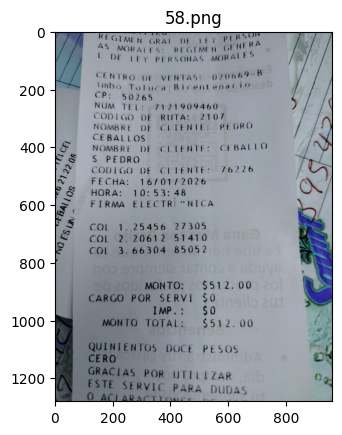

In [669]:

if n <  tickets_errados :

    file_name =  df_ticket_error.iloc[n][RESULTADO_ARCHIVO]

    path = os.path.join(FOLDER_PATH, file_name)

    # Leer Imagen
    image = cv2.imread(path)

    plt.imshow(image)
    plt.title(file_name)

    # Obtener dimensiones de imagen , se requieren porque DOCTR regresa coordenadas de ubicacion del texto 
    # en porcentajes relativos a las dimensiones 
    h, w = image.shape[:2] 

    resultsDocTR = predictor([image])
    cols, resultcode = extraer_columnas(resultsDocTR, h, w,  True)
    if resultcode != CODE_SUCCESS:
        image_clean = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)
        #print("2do Intento -> Imagen Clarificada (predictor)")
        resultsDocTR = predictor([image_clean])
        cols, resultcode = extraer_columnas(resultsDocTR, h, w, True)
        if resultcode != CODE_SUCCESS:
            #print("3er Intento -> Imagen Original (predictor orientation)")
            resultsDocTR = predictor_orientation([image])
            cols, resultcode = extraer_columnas(resultsDocTR, h, w, False)
            if resultcode != CODE_SUCCESS :
                #print("4to Intento -> Imagen Clarificada (predictor orientation)")
                resultsDocTR = predictor_orientation([image_clean])
                cols, resultcode = extraer_columnas(resultsDocTR, h, w, False)


    
    print(cols)

    n += 1

else :
    print("Finalizo revision de tickets errados")